<a href="https://colab.research.google.com/github/sushants05-ops/ECGR-4105---Intro-to-Machine-Learning/blob/main/ECGR_4105_Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Diabetes Dataset Shape:
(768, 9)

First Five Diabetes Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing Diabetes Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age   

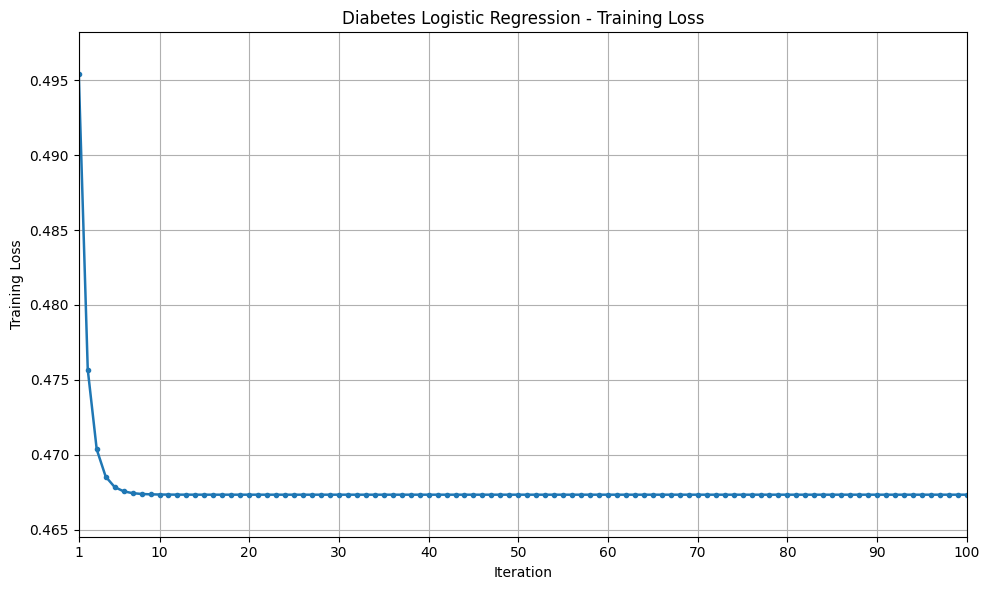

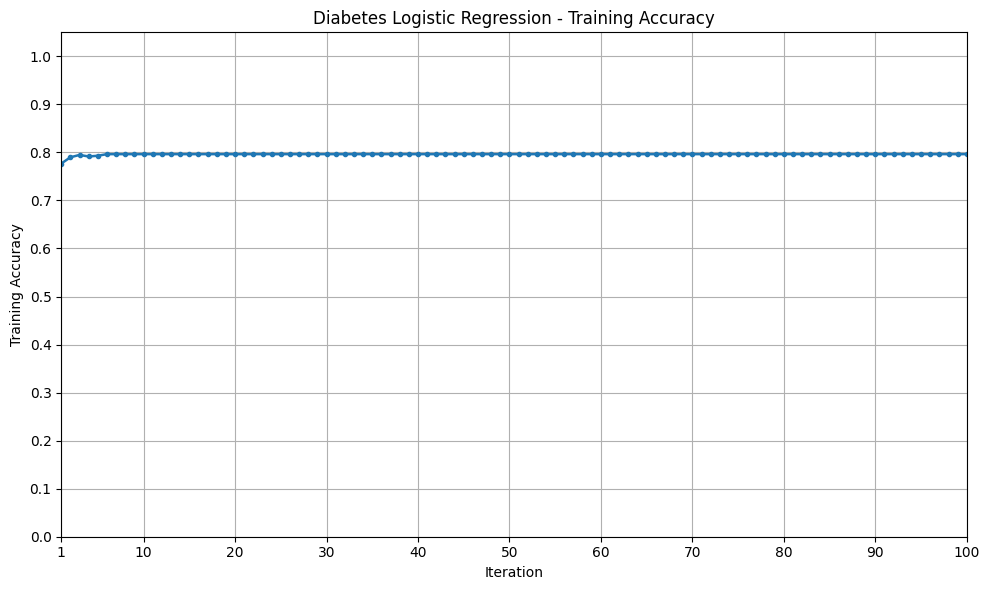

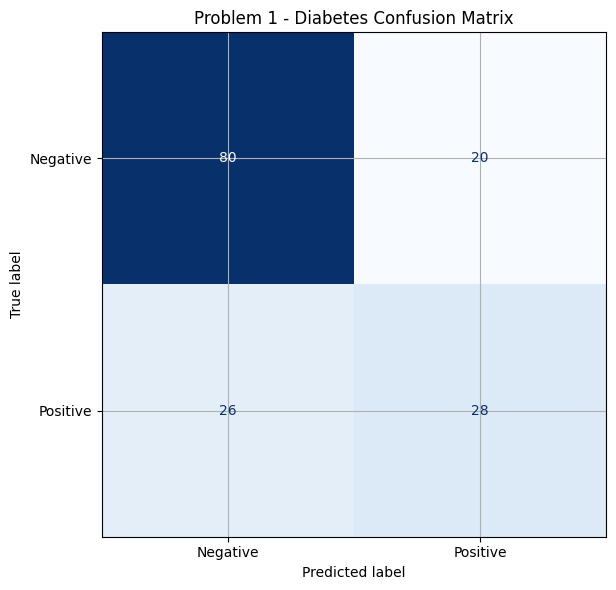


Diabetes Final Results:
   Metric    Value
 Accuracy 0.701299
Precision 0.583333
   Recall 0.518519
 F1 Score 0.549020

Cancer Dataset Shape:
(569, 33)

First Five Cancer Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390   

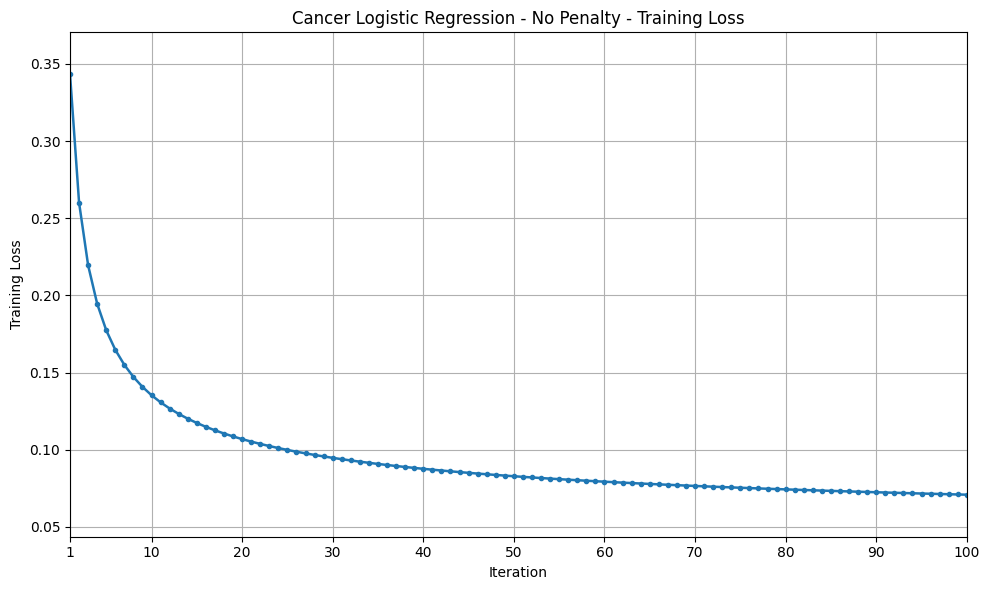

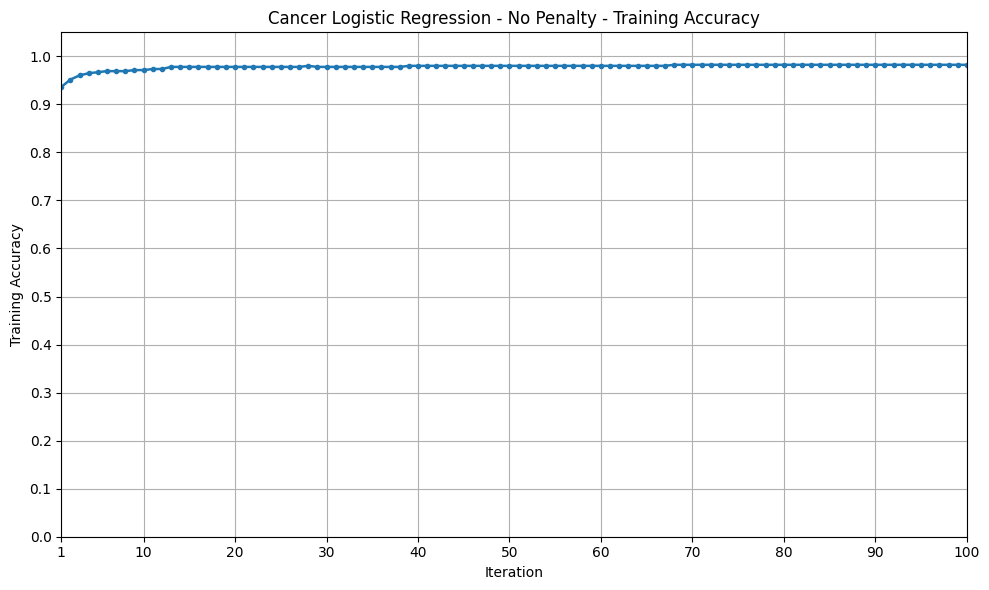

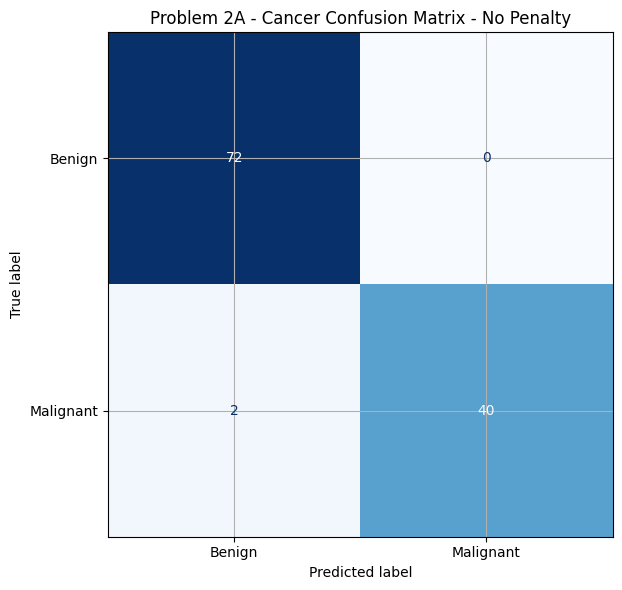


Problem 2B - Cancer Logistic Regression - L2 Penalty
Accuracy :  0.9825
Precision:  1.0000
Recall   :  0.9524
F1 Score :  0.9756

Confusion Matrix:
[[72  0]
 [ 2 40]]


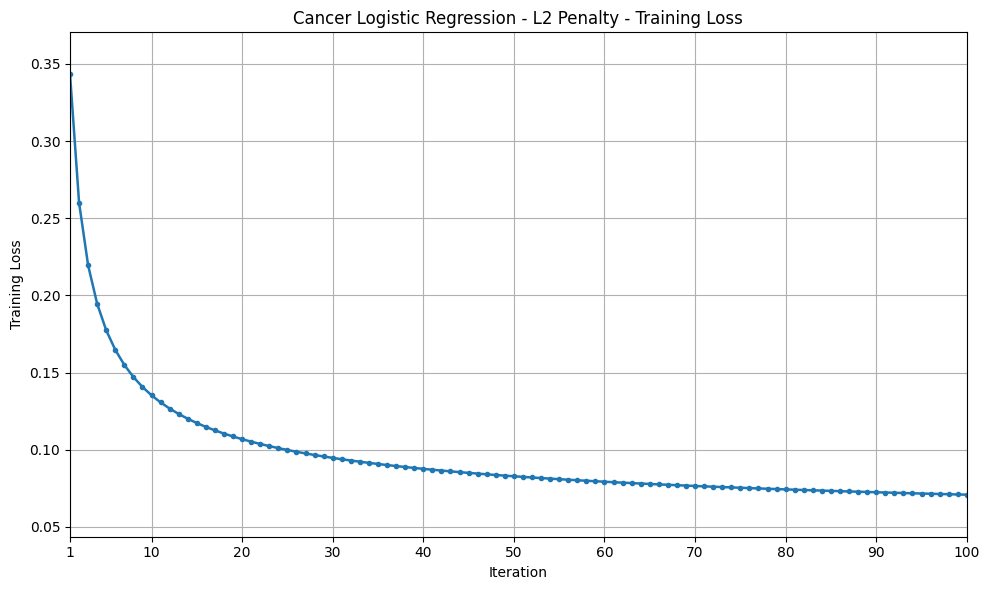

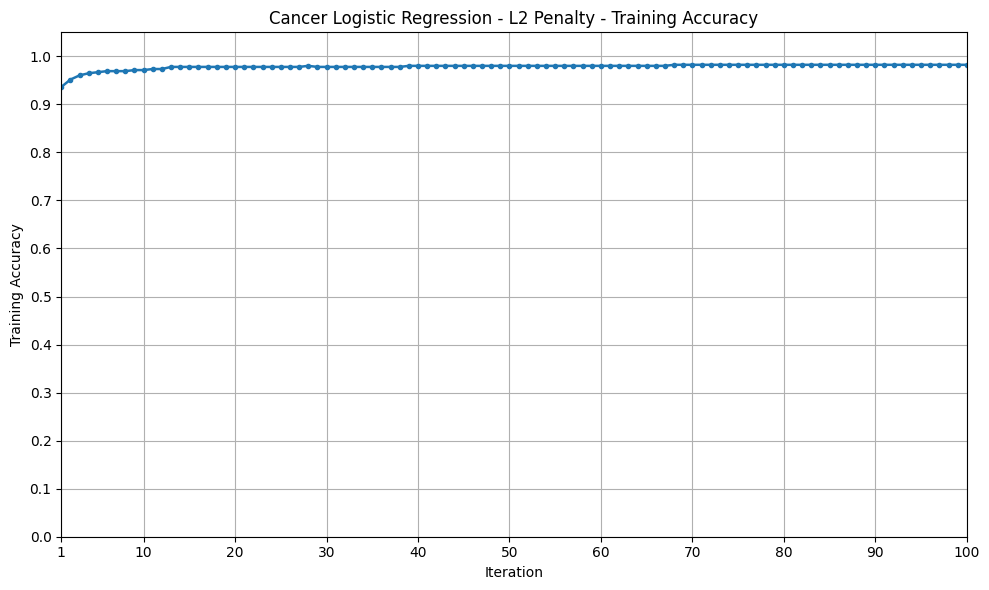

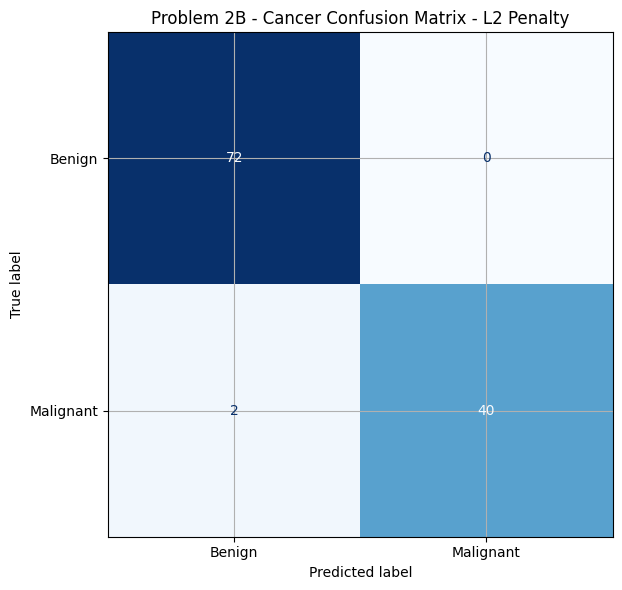


Cancer Model Comparison:
            Model  Accuracy  Precision  Recall  F1 Score
No Weight Penalty    0.9825     1.0000  0.9524    0.9756
L2 Weight Penalty    0.9825     1.0000  0.9524    0.9756

Final Homework 3 Results:
             Problem                            Model  Accuracy  Precision  Recall  F1 Score
Problem 1 - Diabetes Logistic Regression - No Penalty    0.7013     0.5833  0.5185    0.5490
 Problem 2A - Cancer Logistic Regression - No Penalty    0.9825     1.0000  0.9524    0.9756
 Problem 2B - Cancer Logistic Regression - L2 Penalty    0.9825     1.0000  0.9524    0.9756

Results saved successfully.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)

# Set reproducibility
RANDOM_STATE = 42

# Set general figure size
plt.rcParams["figure.figsize"] = (9, 6)


# Train logistic regression and record training history
def train_logistic_regression(
    X_train,
    y_train,
    X_test,
    y_test,
    penalty=None,
    alpha=0.0001,
    learning_rate=0.01,
    epochs=100,
    random_state=42
):

    # Create the logistic regression model
    model = SGDClassifier(
        loss="log_loss",
        penalty=penalty,
        alpha=alpha,
        learning_rate="constant",
        eta0=learning_rate,
        max_iter=1,
        tol=None,
        shuffle=True,
        random_state=random_state,
        fit_intercept=True
    )

    # Create lists for training history
    loss_history = []
    accuracy_history = []

    # Get the possible target classes
    classes = np.unique(y_train)

    # Train one iteration at a time
    for epoch in range(epochs):

        model.partial_fit(
            X_train,
            y_train,
            classes=classes
        )

        # Calculate training probabilities
        train_probabilities = model.predict_proba(X_train)[:, 1]

        # Convert probabilities to predictions
        train_predictions = (
            train_probabilities >= 0.5
        ).astype(int)

        # Calculate training loss
        current_loss = log_loss(
            y_train,
            train_probabilities,
            labels=classes
        )

        # Calculate training accuracy
        current_accuracy = accuracy_score(
            y_train,
            train_predictions
        )

        # Save training results
        loss_history.append(current_loss)
        accuracy_history.append(current_accuracy)

    # Generate final test predictions
    test_probabilities = model.predict_proba(X_test)[:, 1]

    test_predictions = (
        test_probabilities >= 0.5
    ).astype(int)

    # Calculate final test metrics
    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    test_precision = precision_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    # Calculate confusion matrix
    cm = confusion_matrix(
        y_test,
        test_predictions
    )

    # Return model and results
    return {
        "model": model,
        "loss_history": loss_history,
        "accuracy_history": accuracy_history,
        "test_predictions": test_predictions,
        "test_probabilities": test_probabilities,
        "accuracy": test_accuracy,
        "precision": test_precision,
        "recall": test_recall,
        "f1": test_f1,
        "confusion_matrix": cm
    }


# Print final evaluation results
def print_results(results, model_name):

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy :  {results['accuracy']:.4f}")
    print(f"Precision:  {results['precision']:.4f}")
    print(f"Recall   :  {results['recall']:.4f}")
    print(f"F1 Score :  {results['f1']:.4f}")

    print("\nConfusion Matrix:")
    print(results["confusion_matrix"])


# Plot the complete training history
def plot_training_history(results, title):

    # Create iteration numbers
    iterations = np.arange(
        1,
        len(results["loss_history"]) + 1
    )

    # Get loss values
    losses = np.array(
        results["loss_history"]
    )

    # Get accuracy values
    accuracies = np.array(
        results["accuracy_history"]
    )

    # Plot training loss
    plt.figure(figsize=(10, 6))

    plt.plot(
        iterations,
        losses,
        marker="o",
        markersize=3,
        linewidth=1.8
    )

    plt.xlabel("Iteration")
    plt.ylabel("Training Loss")
    plt.title(title + " - Training Loss")
    plt.xlim(1, len(iterations))


    loss_min = losses.min()
    loss_max = losses.max()

    if loss_max == loss_min:
        padding = 0.05
    else:
        padding = (loss_max - loss_min) * 0.10

    plt.ylim(
        max(0, loss_min - padding),
        loss_max + padding
    )

    plt.xticks(
        np.linspace(
            1,
            len(iterations),
            min(11, len(iterations)),
            dtype=int
        )
    )

    plt.tight_layout()
    plt.show()

    # Plot training accuracy
    plt.figure(figsize=(10, 6))

    plt.plot(
        iterations,
        accuracies,
        marker="o",
        markersize=3,
        linewidth=1.8
    )

    plt.xlabel("Iteration")
    plt.ylabel("Training Accuracy")
    plt.title(title + " - Training Accuracy")


    plt.ylim(0, 1.05)

    plt.xlim(1, len(iterations))

    plt.yticks(
        np.arange(
            0,
            1.1,
            0.1
        )
    )

    plt.xticks(
        np.linspace(
            1,
            len(iterations),
            min(11, len(iterations)),
            dtype=int
        )
    )

    plt.tight_layout()
    plt.show()


# Plot the confusion matrix
def plot_confusion_matrix(
    results,
    title,
    class_names
):

    # Get confusion matrix
    cm = results["confusion_matrix"]

    # Create confusion matrix display
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    # Create figure
    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    # Plot matrix
    display.plot(
        ax=ax,
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(title)

    plt.tight_layout()
    plt.show()


# Load diabetes dataset
diabetes = pd.read_csv(
    "/content/diabetes.csv"
)

print("\nDiabetes Dataset Shape:")
print(diabetes.shape)

print("\nFirst Five Diabetes Rows:")
print(diabetes.head())

print("\nMissing Diabetes Values:")
print(diabetes.isnull().sum())

# Separate diabetes features and target
X_diabetes = diabetes.drop(
    columns=["Outcome"]
)

y_diabetes = diabetes["Outcome"]

# Split diabetes data into training and testing sets
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_diabetes
)

print("\nDiabetes Training Samples:")
print(X_train_d.shape[0])

print("Diabetes Testing Samples:")
print(X_test_d.shape[0])

# Standardize diabetes features
scaler_diabetes = StandardScaler()

X_train_d_scaled = scaler_diabetes.fit_transform(
    X_train_d
)

X_test_d_scaled = scaler_diabetes.transform(
    X_test_d
)

# Train diabetes logistic regression
diabetes_results = train_logistic_regression(
    X_train=X_train_d_scaled,
    y_train=y_train_d.to_numpy(),
    X_test=X_test_d_scaled,
    y_test=y_test_d.to_numpy(),
    penalty=None,
    learning_rate=0.01,
    epochs=100,
    random_state=RANDOM_STATE
)

# Print diabetes results
print_results(
    diabetes_results,
    "Problem 1 - Diabetes Logistic Regression"
)

# Plot diabetes training results
plot_training_history(
    diabetes_results,
    "Diabetes Logistic Regression"
)

# Plot diabetes confusion matrix
plot_confusion_matrix(
    diabetes_results,
    "Problem 1 - Diabetes Confusion Matrix",
    ["Negative", "Positive"]
)

# Create diabetes results table
diabetes_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        diabetes_results["accuracy"],
        diabetes_results["precision"],
        diabetes_results["recall"],
        diabetes_results["f1"]
    ]
})

print("\nDiabetes Final Results:")
print(
    diabetes_summary.to_string(
        index=False
    )
)


# Load cancer dataset
cancer = pd.read_csv(
    "/content/Cancer.csv"
)

print("\nCancer Dataset Shape:")
print(cancer.shape)

print("\nFirst Five Cancer Rows:")
print(cancer.head())

print("\nMissing Cancer Values:")
print(cancer.isnull().sum())

# Remove ID, target, and empty column
X_cancer = cancer.drop(
    columns=[
        "id",
        "diagnosis",
        "Unnamed: 32"
    ]
)

# Encode cancer diagnosis
# Benign = 0
# Malignant = 1
y_cancer = cancer["diagnosis"].map({
    "B": 0,
    "M": 1
})

print("\nNumber of Cancer Input Features:")
print(X_cancer.shape[1])

print("\nCancer Target Distribution:")
print(y_cancer.value_counts())

# Split cancer data into training and testing sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cancer
)

print("\nCancer Training Samples:")
print(X_train_c.shape[0])

print("Cancer Testing Samples:")
print(X_test_c.shape[0])

# Standardize cancer features
scaler_cancer = StandardScaler()

X_train_c_scaled = scaler_cancer.fit_transform(
    X_train_c
)

X_test_c_scaled = scaler_cancer.transform(
    X_test_c
)


# Problem 2A: Cancer without weight penalty
cancer_no_penalty_results = train_logistic_regression(
    X_train=X_train_c_scaled,
    y_train=y_train_c.to_numpy(),
    X_test=X_test_c_scaled,
    y_test=y_test_c.to_numpy(),
    penalty=None,
    learning_rate=0.001,
    epochs=100,
    random_state=RANDOM_STATE
)

# Print cancer no-penalty results
print_results(
    cancer_no_penalty_results,
    "Problem 2A - Cancer Logistic Regression - No Penalty"
)

# Plot cancer no-penalty training results
plot_training_history(
    cancer_no_penalty_results,
    "Cancer Logistic Regression - No Penalty"
)

# Plot cancer no-penalty confusion matrix
plot_confusion_matrix(
    cancer_no_penalty_results,
    "Problem 2A - Cancer Confusion Matrix - No Penalty",
    ["Benign", "Malignant"]
)


# Problem 2B: Cancer with L2 weight penalty
cancer_l2_results = train_logistic_regression(
    X_train=X_train_c_scaled,
    y_train=y_train_c.to_numpy(),
    X_test=X_test_c_scaled,
    y_test=y_test_c.to_numpy(),
    penalty="l2",
    alpha=0.0001,
    learning_rate=0.001,
    epochs=100,
    random_state=RANDOM_STATE
)

# Print cancer L2 results
print_results(
    cancer_l2_results,
    "Problem 2B - Cancer Logistic Regression - L2 Penalty"
)

# Plot cancer L2 training results
plot_training_history(
    cancer_l2_results,
    "Cancer Logistic Regression - L2 Penalty"
)

# Plot cancer L2 confusion matrix
plot_confusion_matrix(
    cancer_l2_results,
    "Problem 2B - Cancer Confusion Matrix - L2 Penalty",
    ["Benign", "Malignant"]
)


# Compare the two cancer models
comparison = pd.DataFrame({
    "Model": [
        "No Weight Penalty",
        "L2 Weight Penalty"
    ],
    "Accuracy": [
        cancer_no_penalty_results["accuracy"],
        cancer_l2_results["accuracy"]
    ],
    "Precision": [
        cancer_no_penalty_results["precision"],
        cancer_l2_results["precision"]
    ],
    "Recall": [
        cancer_no_penalty_results["recall"],
        cancer_l2_results["recall"]
    ],
    "F1 Score": [
        cancer_no_penalty_results["f1"],
        cancer_l2_results["f1"]
    ]
})

print("\nCancer Model Comparison:")
print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# Create final results table
all_results = pd.DataFrame({
    "Problem": [
        "Problem 1 - Diabetes",
        "Problem 2A - Cancer",
        "Problem 2B - Cancer"
    ],
    "Model": [
        "Logistic Regression - No Penalty",
        "Logistic Regression - No Penalty",
        "Logistic Regression - L2 Penalty"
    ],
    "Accuracy": [
        diabetes_results["accuracy"],
        cancer_no_penalty_results["accuracy"],
        cancer_l2_results["accuracy"]
    ],
    "Precision": [
        diabetes_results["precision"],
        cancer_no_penalty_results["precision"],
        cancer_l2_results["precision"]
    ],
    "Recall": [
        diabetes_results["recall"],
        cancer_no_penalty_results["recall"],
        cancer_l2_results["recall"]
    ],
    "F1 Score": [
        diabetes_results["f1"],
        cancer_no_penalty_results["f1"],
        cancer_l2_results["f1"]
    ]
})

print("\nFinal Homework 3 Results:")
print(
    all_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# Save result tables
all_results.to_csv(
    "Homework3_Final_Results.csv",
    index=False
)

comparison.to_csv(
    "Homework3_Cancer_Comparison.csv",
    index=False
)

print("\nResults saved successfully.")


